In [1]:
!pip install faker seaborn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random
import json

from faker import Faker
from datetime import datetime,timedelta

import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker()

random.seed(100)
np.random.seed(100)

In [3]:
customers=[]

for i in range(1,5001):

    email=fake.email()

    #2% bad emails
    if random.random()<0.02:
        email=random.choice([
            None,
            "wrongmail",
            "@gmail.com",
            "abc"
        ])

    customers.append({
        "customer_id":i,
        "name":fake.name(),
        "email":email,
        "city":fake.city(),
        "state":fake.state(),
        "created_date":fake.date_between("-3y","today")
    })

customers=pd.DataFrame(customers)

In [4]:
dup=customers.sample(frac=0.01)

customers=pd.concat([customers,dup])

customers.to_csv("customers.csv",index=False)

In [5]:
categories=[
    "Electronics",
    "Books",
    "Fashion",
    "Sports",
    "Home",
    "Toys"
]

products=[]

for i in range(1,901):

    products.append({
        "product_id":i,
        "category":random.choice(categories),
        "unit_price":round(random.uniform(10,800),2),
        "active_flag":random.choice([0,1])
    })

products=pd.DataFrame(products)

products.to_csv("products.csv",index=False)

In [8]:
orders=[]

for i in range(1,20001):

    orders.append({
        "order_id":i,
        "customer_id":random.randint(1,5000),
        "order_ts":str(fake.date_time_between("-10d","now")),
        "store_region":random.choice([
            "North",
            "South",
            "East",
            "West"
        ]),
        "status":random.choice([
            "Completed",
            "Pending",
            "Cancelled"
        ])
    })

orders=pd.DataFrame(orders)

orders.to_json(
    "orders_day1.json",
    orient="records",
    lines=True
)

In [9]:
items=[]

for i in range(55000):

    pid=random.randint(1,900)

    #referential issue
    if random.random()<0.002:
        pid=9999

    qty=random.randint(1,5)

    #negative quantity
    if random.random()<0.002:
        qty=random.choice([0,-2])

    price=round(random.uniform(10,700),2)

    items.append({
        "order_id":random.randint(1,20000),
        "product_id":pid,
        "quantity":qty,
        "unit_price":price,
        "line_total":qty*price
    })

items=pd.DataFrame(items)

items.to_json(
    "order_items_day1.json",
    orient="records",
    lines=True
)

In [11]:
orders2=[]

for i in range(20001,24001):

    orders2.append({
        "order_id":i,
        "customer_id":random.randint(1,5000),
        "order_ts":str(fake.date_time_between("now","+1d")),
        "store_region":random.choice([
            "North",
            "South",
            "East",
            "West"
        ]),
        "status":"Completed"
    })

orders2=pd.DataFrame(orders2)

orders2.to_json(
    "orders_day2.json",
    orient="records",
    lines=True
)

In [12]:
discounts=[
    "DISC10",
    "SAVE5",
    "NEW20",
    None
]

items2=[]

for i in range(11000):

    qty=random.randint(1,5)
    price=round(random.uniform(10,700),2)

    items2.append({
        "order_id":random.randint(20001,24000),
        "product_id":random.randint(1,900),
        "quantity":qty,
        "unit_price":price,
        "line_total":qty*price,
        "discount_code":random.choice(discounts)
    })

items2=pd.DataFrame(items2)

items2.to_json(
    "order_items_day2.json",
    orient="records",
    lines=True
)

In [13]:
import pandas as pd

def profile_dataset(df, name):
    print("=" * 80)
    print(f"DATA PROFILE: {name}")
    print("=" * 80)

    # 1. Shape
    print(f"\nRows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    # 2. Dtype Summary
    print("\nData Types")
    print(df.dtypes)

    # 3. Null Counts & Null %
    print("\nMissing Values")
    null_summary = pd.DataFrame({
        "Null Count": df.isnull().sum(),
        "Null %": (df.isnull().mean() * 100).round(2)
    })
    print(null_summary)

    # 4. Duplicate Rows
    print("\nDuplicate Rows:", df.duplicated().sum())

    # 5. Value Ranges (Numeric Columns)
    print("\nNumeric Value Ranges")
    numeric = df.select_dtypes(include="number")

    if not numeric.empty:
        value_ranges = pd.DataFrame({
            "Minimum": numeric.min(),
            "Maximum": numeric.max(),
            "Mean": numeric.mean().round(2)
        })
        print(value_ranges)

    # 6. Categorical Summary
    print("\nCategorical Columns")

    categorical = df.select_dtypes(include="object")

    for col in categorical.columns:
        print(f"\n{col}")
        print(df[col].value_counts().head(10))

In [14]:
profile_dataset(customers, "Customers")
profile_dataset(products, "Products")
profile_dataset(orders, "Orders Day 1")
profile_dataset(items, "Order Items Day 1")
profile_dataset(orders2, "Orders Day 2")
profile_dataset(items2, "Order Items Day 2")

DATA PROFILE: Customers

Rows: 5050
Columns: 6

Data Types
customer_id      int64
name            object
email           object
city            object
state           object
created_date    object
dtype: object

Missing Values
              Null Count  Null %
customer_id            0    0.00
name                   0    0.00
email                 17    0.34
city                   0    0.00
state                  0    0.00
created_date           0    0.00

Duplicate Rows: 50

Numeric Value Ranges
             Minimum  Maximum     Mean
customer_id        1     5000  2498.59

Categorical Columns

name
name
Lisa Johnson          5
Jessica Williams      4
Michael Smith         3
Michael Palmer        3
Elizabeth Johnson     3
David Gonzalez        3
Justin Smith          3
Heather Collins       3
Christopher Thomas    3
Cynthia Smith         3
Name: count, dtype: int64

email
email
wrongmail               31
@gmail.com              29
abc                     28
jjones@example.net       3
ash

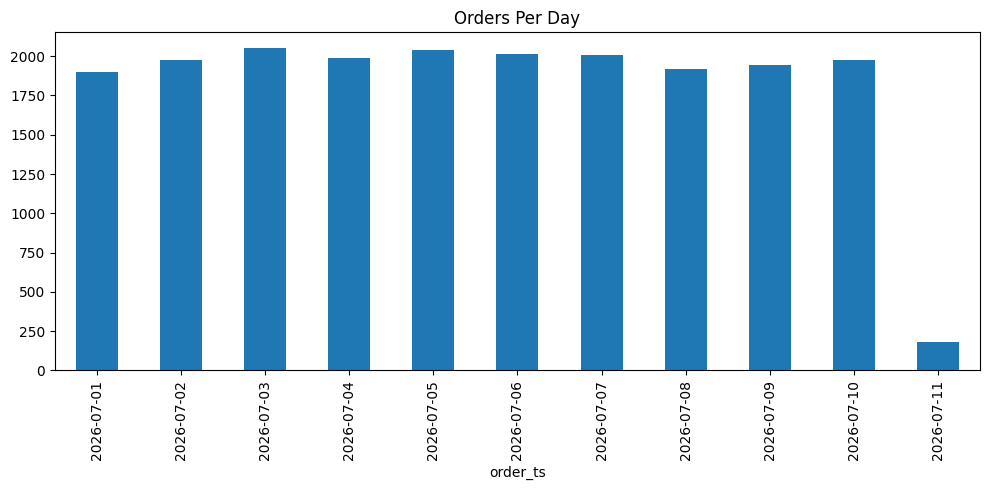

In [15]:
orders["order_ts"]=pd.to_datetime(orders["order_ts"])

daily=orders.groupby(
    orders["order_ts"].dt.date
).size()

plt.figure(figsize=(10,5))
daily.plot(kind="bar")
plt.title("Orders Per Day")
plt.tight_layout()
plt.savefig("orders_per_day.png")

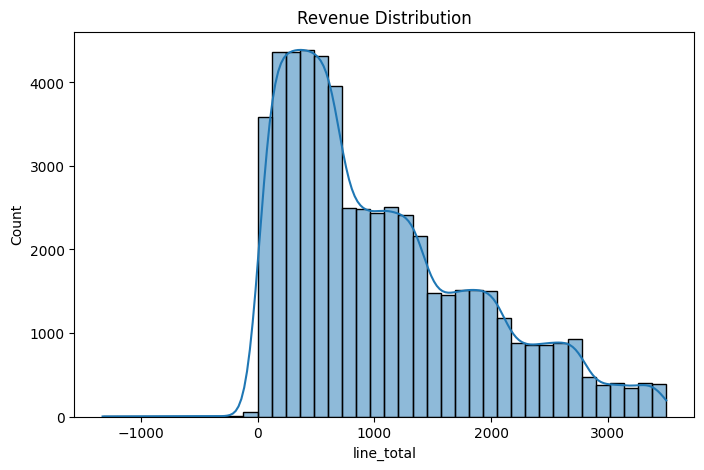

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    items["line_total"],
    bins=40,
    kde=True
)

plt.title("Revenue Distribution")

plt.savefig("revenue_distribution.png")

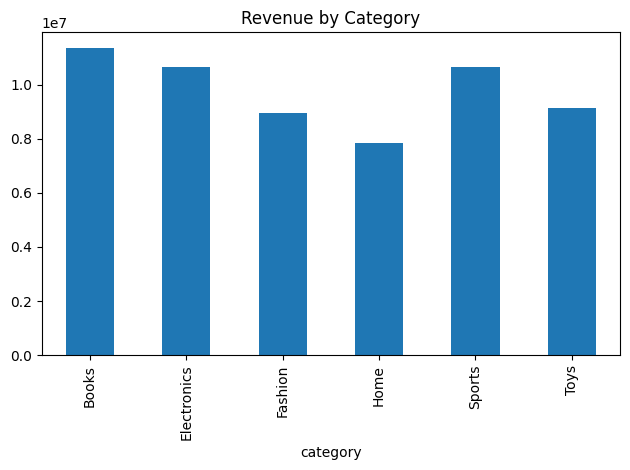

In [17]:
merged=items.merge(products,on="product_id",how="left")

cat=merged.groupby("category")["line_total"].sum()

cat.plot(kind="bar")

plt.title("Revenue by Category")

plt.tight_layout()

plt.savefig("top_categories.png")

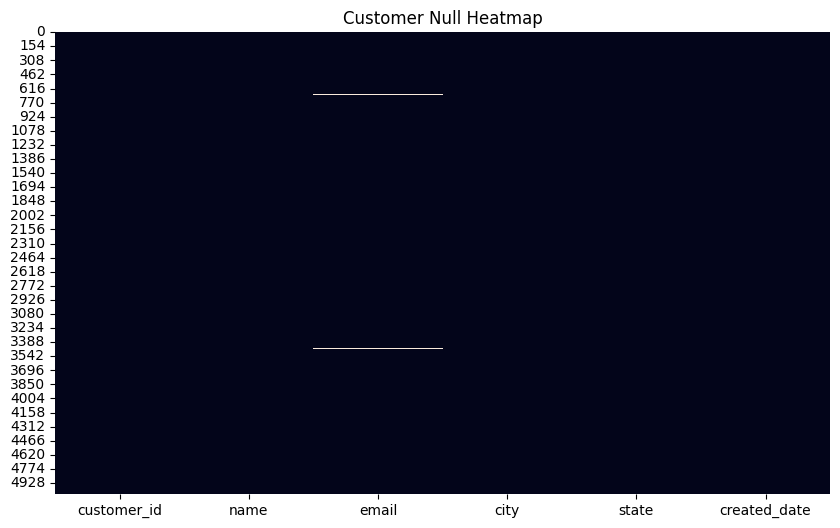

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    customers.isnull(),
    cbar=False
)

plt.title("Customer Null Heatmap")

plt.savefig("null_heatmap.png")

In [19]:
report="""
# Data Profile Report

## Customers
- Rows: 5050
- 2% invalid emails
- 1% duplicate customer IDs

## Products
- 900 products

## Orders
- Day1: 20,000
- Day2: 4,000

## Order Items
- Referential integrity failures
- Negative quantity records
- Schema evolution using discount_code

## Charts Generated

- Orders per Day
- Revenue Distribution
- Revenue by Category
- Null Heatmap
"""

with open("data_profile_report.md","w") as f:
    f.write(report)